In [1]:
with open("./within_project_ASMOTE_LightGBM.txt", "r") as file:
    results = file.read()

results

'ANTLR4 & 38.79\\% & 31.19\\% & 33.77\\% & 81.93\\% & 27.09\\% & 43.02\\% & 35.00\\% & 37.53\\% & 77.57\\% & 28.63\\% & 26.17\\% & 15.33\\% & 17.69\\% & 71.60\\% & 16.15\\% & \\enspace4.11\\% & 11.67\\% & \\enspace6.04\\% & 54.83\\% & \\enspace3.17\\%\\\\\nDBeaver & 27.85\\% & 24.47\\% & 24.45\\% & 77.02\\% & 21.59\\% & 29.04\\% & 31.60\\% & 30.13\\% & 76.85\\% & 25.41\\% & 16.93\\% & 27.85\\% & 20.99\\% & 69.07\\% & 16.61\\% & 44.46\\% & 12.14\\% & 14.20\\% & 63.33\\% & 17.90\\%\\\\\nElasticsearch & 38.09\\% & 35.97\\% & 35.56\\% & 79.72\\% & 31.01\\% & 35.56\\% & 33.50\\% & 34.43\\% & 72.92\\% & 26.50\\% & 25.31\\% & 24.77\\% & 15.38\\% & 70.92\\% & 14.64\\% & \\enspace7.37\\% & 31.18\\% & 11.91\\% & 61.80\\% & \\enspace8.53\\%\\\\\nExoPlayer & 49.71\\% & 46.03\\% & 47.48\\% & 76.15\\% & 36.23\\% & 43.97\\% & 41.97\\% & 42.83\\% & 75.60\\% & 32.24\\% & 86.64\\% & 46.33\\% & 60.14\\% & 85.87\\% & 61.70\\% & 66.49\\% & 33.41\\% & 43.98\\% & 77.30\\% & 45.78\\%\\\\\nFastJSON & 49.88\\% 

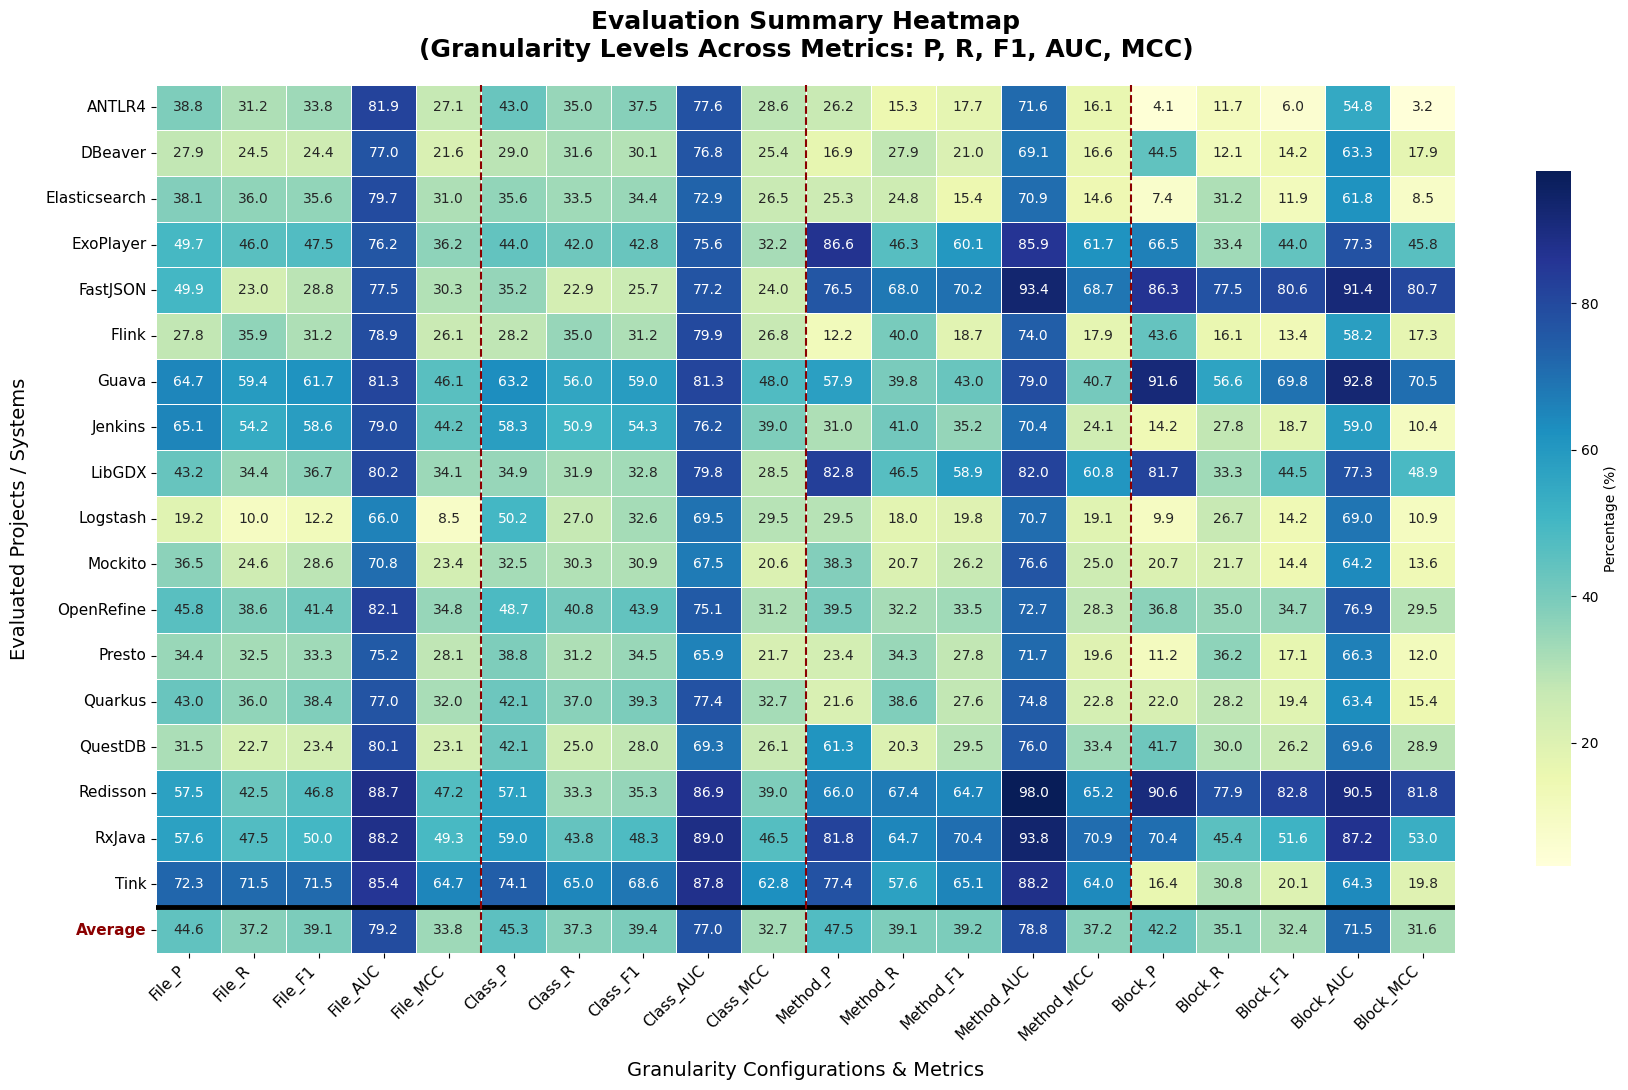

In [5]:
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. Parse the Data ---
rows = []
for line in results.strip().split("\n"):
    if not line.strip():
        continue

    line = line.replace(r"\\", "")
    line = line.replace(r"\textbf{Average}", "Average")

    parts = [p.strip() for p in line.split("&")]
    project_name = parts[0]

    values = []
    for p in parts[1:]:
        val_str = p.replace(r"\%", "").replace(r"\enspace", "").strip()
        if val_str:
            values.append(float(val_str))

    rows.append([project_name] + values)

# --- 2. Build Structural Labels (4 Custom Configs x 5 Metrics) ---
configs = ["File", "Class", "Method", "Block"]
base_metrics = ["P", "R", "F1", "AUC", "MCC"]
column_names = ["Project"]

for config in configs:
    for metric in base_metrics:
        column_names.append(f"{config}_{metric}")

# Convert to DataFrame
df = pd.DataFrame(rows, columns=column_names).set_index("Project")

# Keep 'Average' row locked at the bottom
project_order = [idx for idx in df.index if idx != "Average"] + ["Average"]
df = df.reindex(project_order)

# --- 3. Plot the Custom Heatmap ---
fig, ax = plt.subplots(figsize=(18, 11))

sns.heatmap(
    df,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.4,
    cbar_kws={"label": "Percentage (%)", "shrink": 0.8},
    annot_kws={"size": 10},
    ax=ax,
)

# Bold horizontal separator line above 'Average'
ax.axhline(len(df) - 1, color="black", linewidth=3.5, linestyle="-")

# Red vertical separator lines to segment structural scopes (File, Class, Method, Block)
for i in range(1, 4):
    ax.axvline(i * 5, color="darkred", linestyle="--", linewidth=1.5)

# Styling adjustments
ax.set_title(
    "Evaluation Summary Heatmap\n(Granularity Levels Across Metrics: P, R, F1, AUC, MCC)",
    fontsize=18,
    pad=20,
    weight="bold",
)
ax.set_xlabel("Granularity Configurations & Metrics", fontsize=14, labelpad=12)
ax.set_ylabel("Evaluated Projects / Systems", fontsize=14, labelpad=12)

# Format ticks cleanly
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Highlight 'Average' index text
for label in ax.get_yticklabels():
    if label.get_text() == "Average":
        label.set_weight("bold")
        label.set_color("darkred")

plt.tight_layout()
plt.show()